# Cross-Country Analysis — Russia vs China (H3-A)

**Гипотеза H3-A (reformulated):** структура риск-факторов IT-компаний **различается** между рынками с разными режимами капитала.
* Россия (дорогой капитал) → доминирует **ликвидность**.
* Китай (господдержка, ограниченный рынок корпоративного долга) → доминирует **иной** класс факторов (profitability/innovation/size).

### Почему H3 переформулирована
Изначальная формулировка `PIT > TTC` не воспроизводится на малой дефолтной выборке Китая: TTC достигает ceiling ROC ≈ 1.0, и макро-слой не даёт статистически значимого лифта. Поэтому основной тест — **сравнительная структура Σ|SHAP| по блокам** между двумя странами. Макро-слой (PIT) оставлен как вспомогательный численный контроль и инфраструктура для будущей замены placeholder-данных реальными IMF WEO.

### Методологические принципы
* **Company-level split**: обе страны тренируются на 80/20 по тикеру/регистрационному номеру — никакой компании нет одновременно в train и test.
* **Unified target**: во всех странах `target=1` на последних K=2 годах перед дефолтом (event-based, window = 2 года).
* **Symmetric Innovation group**: только `intangibles_to_assets`, чтобы SHAP-суммы были честно сопоставимы.
* **Bootstrap CI**: 500 ресэмплов по компаниям даёт 95%-CI для ROC-AUC и ΔROC.

### Сэмпл
* Россия: ~88k строк, ~400 рядов с target=1 из 206 компаний-банкротов.
* Китай: 3458 строк, 19 рядов с target=1 из 11 default-компаний.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import shap

RNG = 42
N_BOOTSTRAP = 500
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports/cross_country')
REPORTS.mkdir(parents=True, exist_ok=True)

YEARS = range(2014, 2025)
print('Common window:', list(YEARS))

Common window: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 1. Загрузка и приведение к единой схеме

Каждая панель приводится к **тем же** 15 финансовым ratios, что и в `20_russia`/`40_china`. Абсолютные суммы в RUB/CNY никогда не сравниваются — только относительные показатели.

In [2]:
ru_raw = pd.read_csv(PROCESSED / 'ru_panel_cleaned.csv', encoding='utf-8-sig')
cn_raw = pd.read_csv(PROCESSED / 'cn_panel_enriched.csv', encoding='utf-8-sig')

RU = {
    'ID': 'Регистрационный номер', 'TARGET': 'is_bankrupt', 'YEAR': 'year',
    'A': 'Активы  всего', 'CA': 'Оборотные активы',
    'CASH': 'Денежные средства и денежные эквиваленты',
    'INT_A': 'Нематериальные активы', 'EQ': 'Капитал и резервы',
    'LT_L': 'Долгосрочные обязательства', 'ST_L': 'Краткосрочные обязательства',
    'REV': 'Выручка', 'EBIT': 'EBIT', 'NI': 'Чистая прибыль (убыток)',
    'INTEREST': 'Проценты к уплате',
    'CFO': 'Сальдо денежных потоков от текущих операций',
}

def safe_div(a, b):
    b = b.replace(0, np.nan)
    return a / b

def build_ratios_ru(df):
    d = df.copy()
    total_debt = d[RU['LT_L']] + d[RU['ST_L']]
    out = pd.DataFrame({
        'ticker': d[RU['ID']].astype(str),
        'year':   d[RU['YEAR']].astype(int),
        'target': d[RU['TARGET']].astype(int),
    })
    out['current_ratio']         = safe_div(d[RU['CA']], d[RU['ST_L']])
    out['cash_to_assets']        = safe_div(d[RU['CASH']], d[RU['A']])
    out['cash_to_cl']            = safe_div(d[RU['CASH']], d[RU['ST_L']])
    out['wc_to_assets']          = safe_div(d[RU['CA']] - d[RU['ST_L']], d[RU['A']])
    out['intangibles_to_assets'] = safe_div(d[RU['INT_A']], d[RU['A']])
    out['debt_to_assets']        = safe_div(total_debt, d[RU['A']])
    out['debt_to_equity']        = safe_div(total_debt, d[RU['EQ']])
    out['lt_debt_to_assets']     = safe_div(d[RU['LT_L']], d[RU['A']])
    out['interest_coverage']     = safe_div(d[RU['EBIT']], d[RU['INTEREST']])
    out['roa']                   = safe_div(d[RU['NI']], d[RU['A']])
    out['net_margin']            = safe_div(d[RU['NI']], d[RU['REV']])
    out['operating_margin']      = safe_div(d[RU['EBIT']], d[RU['REV']])
    out['cfo_to_assets']         = safe_div(d[RU['CFO']], d[RU['A']])
    out['log_assets']            = np.log1p(d[RU['A']].clip(lower=0))
    out['log_revenue']           = np.log1p(d[RU['REV']].clip(lower=0))
    return out

def build_ratios_cn(df):
    d = df.copy()
    lt_liab = (d['total_liab'] - d['current_liab']).clip(lower=0)
    out = pd.DataFrame({
        'ticker': d['ticker'].astype(str),
        'year':   d['year'].astype(int),
        'target': d['target'].astype(int),
    })
    out['current_ratio']         = safe_div(d['current_assets'], d['current_liab'])
    out['cash_to_assets']        = safe_div(d['cash'], d['total_assets'])
    out['cash_to_cl']            = safe_div(d['cash'], d['current_liab'])
    out['wc_to_assets']          = safe_div(d['current_assets'] - d['current_liab'], d['total_assets'])
    out['intangibles_to_assets'] = safe_div(d['intangibles'], d['total_assets'])
    # Leverage: CN использует total_debt (реальные процентные), чтобы быть
    # методологически близко к российскому LT_L+ST_L (total_liab в CN шире).
    out['debt_to_assets']        = safe_div(d['total_debt'], d['total_assets'])
    out['debt_to_equity']        = safe_div(d['total_debt'], d['total_equity'])
    out['lt_debt_to_assets']     = safe_div(lt_liab, d['total_assets'])
    out['interest_coverage']     = safe_div(d['ebit'], d['interest_expense'])
    out['roa']                   = safe_div(d['net_profit'], d['total_assets'])
    out['net_margin']            = safe_div(d['net_profit'], d['total_revenue'])
    out['operating_margin']      = safe_div(d['ebit'], d['total_revenue'])
    out['cfo_to_assets']         = safe_div(d['cfo'], d['total_revenue'])  # CFO/REV для единообразия? NO — /assets
    out['cfo_to_assets']         = safe_div(d['cfo'], d['total_assets'])
    out['log_assets']            = np.log1p(d['total_assets'].clip(lower=0))
    out['log_revenue']           = np.log1p(d['total_revenue'].clip(lower=0))
    return out

FEATURES = [
    'current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets',
    'intangibles_to_assets',
    'debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage',
    'roa', 'net_margin', 'operating_margin', 'cfo_to_assets',
    'log_assets', 'log_revenue',
]
FEATURE_GROUPS = {
    'Liquidity':     ['current_ratio', 'cash_to_assets', 'cash_to_cl', 'wc_to_assets'],
    'Innovation':    ['intangibles_to_assets'],  # symmetric RU ↔ CN
    'Leverage':      ['debt_to_assets', 'debt_to_equity', 'lt_debt_to_assets', 'interest_coverage'],
    'Profitability': ['roa', 'net_margin', 'operating_margin', 'cfo_to_assets'],
    'Size':          ['log_assets', 'log_revenue'],
}

def preprocess(panel):
    p = panel[panel['year'].isin(list(YEARS))].copy()
    p[FEATURES] = p[FEATURES].replace([np.inf, -np.inf], np.nan)
    for c in FEATURES:
        lo, hi = p[c].quantile([0.01, 0.99])
        p[c] = p[c].clip(lo, hi)
    p[FEATURES] = p[FEATURES].fillna(p[FEATURES].median(numeric_only=True))
    return p

ru = preprocess(build_ratios_ru(ru_raw))
cn = preprocess(build_ratios_cn(cn_raw))
print(f'Russia: {ru.shape}  defaults (row-level, K=2 window) = {int(ru["target"].sum())}')
print(f'China:  {cn.shape}   defaults (row-level, K=2 window) = {int(cn["target"].sum())}')
print(f'Russia companies with target=1: {ru.loc[ru.target==1, "ticker"].nunique()}')
print(f'China  companies with target=1: {cn.loc[cn.target==1, "ticker"].nunique()}')

Russia: (74378, 18)  defaults (row-level, K=2 window) = 321
China:  (3458, 18)   defaults (row-level, K=2 window) = 19
Russia companies with target=1: 201
China  companies with target=1: 11


## 2. Company-level 80/20 split

Обязательная защита от leakage: сплит по компании, а не по строкам. Функция `company_split` стратифицирует отдельно default/active-тикеры.

In [3]:
def company_split(panel, test_frac=0.20, seed=RNG):
    label = panel.groupby('ticker')['target'].max()
    pos = np.array(label[label == 1].index.values, copy=True)
    neg = np.array(label[label == 0].index.values, copy=True)
    rng = np.random.default_rng(seed)
    rng.shuffle(pos); rng.shuffle(neg)
    def _split(arr):
        n_te = max(1, int(round(len(arr) * test_frac)))
        return arr[n_te:], arr[:n_te]
    tr_pos, te_pos = _split(pos)
    tr_neg, te_neg = _split(neg)
    tr_ids = set(tr_pos) | set(tr_neg)
    te_ids = set(te_pos) | set(te_neg)
    return panel['ticker'].isin(tr_ids).values, panel['ticker'].isin(te_ids).values

ru_tr, ru_te = company_split(ru)
cn_tr, cn_te = company_split(cn)
print(f'Russia: train={ru_tr.sum()}, test={ru_te.sum()}, '
      f'test defaults={int(ru.loc[ru_te, "target"].sum())}')
print(f'China:  train={cn_tr.sum()}, test={cn_te.sum()}, '
      f'test defaults={int(cn.loc[cn_te, "target"].sum())}')

Russia: train=59373, test=15005, test defaults=65
China:  train=2772, test=686, test defaults=2


## 3. Stage-1 TTC — LogReg на каждой стране (group-aware)

`ttc_score = predict_proba[:, 1]` — это company-specific интенсивность риска, независимая от года. Используем LogReg для надёжности на малой CN-выборке (см. H1).

In [4]:
def fit_ttc(panel, tr_mask, te_mask, seed=RNG):
    X = panel[FEATURES].values
    y = panel['target'].values
    y_tr, y_te = y[tr_mask], y[te_mask]
    pos_w = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight={0: 1, 1: pos_w},
                                   solver='liblinear', random_state=seed)),
    ])
    pipe.fit(X[tr_mask], y_tr)
    proba_all = pipe.predict_proba(X)[:, 1]
    auc_tr = roc_auc_score(y_tr, pipe.predict_proba(X[tr_mask])[:, 1])
    auc_te = roc_auc_score(y_te, pipe.predict_proba(X[te_mask])[:, 1])
    pr_tr  = average_precision_score(y_tr, pipe.predict_proba(X[tr_mask])[:, 1])
    pr_te  = average_precision_score(y_te, pipe.predict_proba(X[te_mask])[:, 1])
    return pipe, proba_all, auc_tr, auc_te, pr_tr, pr_te

ru_model, ru_ttc, ru_auc_tr, ru_auc_te, ru_pr_tr, ru_pr_te = fit_ttc(ru, ru_tr, ru_te)
cn_model, cn_ttc, cn_auc_tr, cn_auc_te, cn_pr_tr, cn_pr_te = fit_ttc(cn, cn_tr, cn_te)

ru = ru.assign(ttc_score=ru_ttc)
cn = cn.assign(ttc_score=cn_ttc)

ttc_tbl = pd.DataFrame({
    'Country': ['Russia', 'China'],
    'TTC ROC-AUC train': [ru_auc_tr, cn_auc_tr],
    'TTC ROC-AUC test':  [ru_auc_te, cn_auc_te],
    'TTC PR-AUC train':  [ru_pr_tr, cn_pr_tr],
    'TTC PR-AUC test':   [ru_pr_te, cn_pr_te],
    'PR baseline (prevalence)': [ru_te.sum() and ru.loc[ru_te, "target"].mean() or 0,
                                  cn_te.sum() and cn.loc[cn_te, "target"].mean() or 0],
}).set_index('Country').round(4)
ttc_tbl.to_csv(REPORTS / 'h3a_ttc_table.csv', encoding='utf-8-sig')
ttc_tbl

,TTC ROC-AUC train,TTC ROC-AUC test,TTC PR-AUC train,TTC PR-AUC test,PR baseline (prevalence)
Country,,,,,
Russia,0.8585,0.8291,0.0588,0.0888,0.0043
China,0.9974,1.0000,0.6026,1.0000,0.0029


## 4. Bootstrap 95%-CI по компаниям для ΔROC/ΔPR

Ресэмпл на уровне тикера (не строки) — сохраняет независимость единиц наблюдения. 500 итераций.

In [5]:
def bootstrap_ci(panel, te_mask, model, n_boot=N_BOOTSTRAP, seed=RNG):
    rng = np.random.default_rng(seed)
    te = panel.loc[te_mask].copy()
    tickers = te['ticker'].unique()
    X = te[FEATURES].values
    y = te['target'].values
    proba = model.predict_proba(X)[:, 1]
    te['_proba'] = proba
    roc, pr = [], []
    by_ticker = {t: te.loc[te['ticker'] == t, ['target', '_proba']].values for t in tickers}
    for _ in range(n_boot):
        sample = rng.choice(tickers, size=len(tickers), replace=True)
        rows = np.concatenate([by_ticker[t] for t in sample])
        yb, pb = rows[:, 0].astype(int), rows[:, 1]
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue
        roc.append(roc_auc_score(yb, pb))
        pr.append(average_precision_score(yb, pb))
    return np.percentile(roc, [2.5, 97.5]), np.percentile(pr, [2.5, 97.5])

ru_roc_ci, ru_pr_ci = bootstrap_ci(ru, ru_te, ru_model)
cn_roc_ci, cn_pr_ci = bootstrap_ci(cn, cn_te, cn_model)

ci_tbl = pd.DataFrame({
    'Country': ['Russia', 'China'],
    'TTC ROC test (mean)': [ru_auc_te, cn_auc_te],
    'TTC ROC 95%-CI':      [f'[{ru_roc_ci[0]:.3f}, {ru_roc_ci[1]:.3f}]',
                            f'[{cn_roc_ci[0]:.3f}, {cn_roc_ci[1]:.3f}]'],
    'TTC PR test (mean)':  [ru_pr_te, cn_pr_te],
    'TTC PR 95%-CI':       [f'[{ru_pr_ci[0]:.3f}, {ru_pr_ci[1]:.3f}]',
                            f'[{cn_pr_ci[0]:.3f}, {cn_pr_ci[1]:.3f}]'],
}).set_index('Country')
ci_tbl.to_csv(REPORTS / 'h3a_ttc_bootstrap_ci.csv', encoding='utf-8-sig')
ci_tbl

,TTC ROC test (mean),TTC ROC 95%-CI,TTC PR test (mean),TTC PR 95%-CI
Country,,,,
Russia,0.829057,"[0.753, 0.886]",0.088791,"[0.021, 0.174]"
China,1.000000,"[1.000, 1.000]",1.000000,"[1.000, 1.000]"


## 5. Macro-данные (PLACEHOLDER — заменить IMF WEO перед защитой)

Функция `load_macro(country)` изолирована: при замене числами из официальных источников (IMF WEO: `NGDP_RPCH`, `PCPIPCH` / Росстат / NBS) весь остальной код работает без изменений.

> ⚠️ **TODO:** до защиты заменить значения в словаре `_MACRO_PLACEHOLDER` на реальные из IMF WEO. Сейчас цифры — правдоподобные публичные оценки, но для формальных выводов их нельзя использовать.

In [6]:
# REPLACE_WITH_IMF_WEO — before defence replace values below with official IMF WEO data.
# IMF WEO download: https://www.imf.org/en/Publications/WEO/weo-database
# Variables: NGDP_RPCH (Gross domestic product, constant prices), PCPIPCH (Inflation, average consumer prices)
_MACRO_PLACEHOLDER = {
    'Russia': {
        2014: (0.7, 11.4), 2015: (-2.0, 12.9), 2016: (0.2, 5.4),  2017: (1.8, 2.5),
        2018: (2.8, 4.3),  2019: (2.2, 3.0),   2020: (-2.7, 3.4), 2021: (5.6, 6.7),
        2022: (-1.2, 13.8), 2023: (3.6, 7.4),  2024: (3.9, 8.3),
    },
    'China': {
        2014: (7.4, 2.0),  2015: (7.0, 1.4), 2016: (6.9, 2.0), 2017: (6.9, 1.6),
        2018: (6.8, 2.1),  2019: (6.0, 2.9), 2020: (2.2, 2.5), 2021: (8.4, 0.9),
        2022: (3.0, 2.0),  2023: (5.2, 0.2), 2024: (5.0, 0.4),
    },
}

def load_macro(country: str) -> pd.DataFrame:
    src = _MACRO_PLACEHOLDER[country]
    return pd.DataFrame([(y, g, i) for y, (g, i) in src.items()],
                        columns=['year', 'GDP_Growth', 'Inflation_Rate'])

macro_ru = load_macro('Russia')
macro_cn = load_macro('China')
ru = ru.merge(macro_ru, on='year', how='left')
cn = cn.merge(macro_cn, on='year', how='left')
print('Macro merged (placeholder).')

Macro merged (placeholder).


## 6. Stage-2 PIT comparison (group-aware, вспомогательный)

Один и тот же 80/20 company-split, что и в Stage-1. `ΔROC = PIT − TTC` проверяется на bootstrap 95%-CI — если CI пересекает 0, макро-лифт статистически незначим.

In [7]:
def compare_ttc_vs_pit(panel, tr_mask, te_mask, seed=RNG):
    X_ttc = panel[['ttc_score']].values
    X_pit = panel[['ttc_score', 'GDP_Growth', 'Inflation_Rate']].values
    y = panel['target'].values
    pos_w = float((y[tr_mask] == 0).sum() / max((y[tr_mask] == 1).sum(), 1))
    def _fit(X):
        m = LogisticRegression(max_iter=2000, class_weight={0: 1, 1: pos_w},
                               solver='liblinear', random_state=seed)
        m.fit(X[tr_mask], y[tr_mask])
        return m, m.predict_proba(X[te_mask])[:, 1]
    m_ttc, p_ttc = _fit(X_ttc)
    m_pit, p_pit = _fit(X_pit)
    y_te = y[te_mask]
    return {
        'TTC ROC test': roc_auc_score(y_te, p_ttc),
        'PIT ROC test': roc_auc_score(y_te, p_pit),
        'ΔROC (PIT−TTC)': roc_auc_score(y_te, p_pit) - roc_auc_score(y_te, p_ttc),
        'TTC PR test':  average_precision_score(y_te, p_ttc),
        'PIT PR test':  average_precision_score(y_te, p_pit),
    }, (p_ttc, p_pit)

ru_pit_row, (ru_p_ttc, ru_p_pit) = compare_ttc_vs_pit(ru, ru_tr, ru_te)
cn_pit_row, (cn_p_ttc, cn_p_pit) = compare_ttc_vs_pit(cn, cn_tr, cn_te)

pit_tbl = pd.DataFrame([
    {'Country': 'Russia', **ru_pit_row},
    {'Country': 'China',  **cn_pit_row},
]).set_index('Country').round(4)
pit_tbl.to_csv(REPORTS / 'h3a_pit_vs_ttc.csv', encoding='utf-8-sig')
print('PIT vs TTC (placeholder-macro — cautious interpretation):')
pit_tbl

PIT vs TTC (placeholder-macro — cautious interpretation):


,TTC ROC test,PIT ROC test,ΔROC (PIT−TTC),TTC PR test,PIT PR test
Country,,,,,
Russia,0.8291,0.8370,0.0079,0.0888,0.0533
China,1.0000,0.9978,-0.0022,1.0000,0.5000


In [8]:
# Bootstrap CI на ΔROC (PIT−TTC) по компаниям
def bootstrap_delta(panel, te_mask, p_ttc, p_pit, n_boot=N_BOOTSTRAP, seed=RNG):
    rng = np.random.default_rng(seed)
    te = panel.loc[te_mask].copy()
    te['_p_ttc'] = p_ttc; te['_p_pit'] = p_pit
    tickers = te['ticker'].unique()
    by_ticker = {t: te.loc[te['ticker'] == t, ['target', '_p_ttc', '_p_pit']].values for t in tickers}
    deltas = []
    for _ in range(n_boot):
        sample = rng.choice(tickers, size=len(tickers), replace=True)
        rows = np.concatenate([by_ticker[t] for t in sample])
        yb = rows[:, 0].astype(int)
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue
        d = roc_auc_score(yb, rows[:, 2]) - roc_auc_score(yb, rows[:, 1])
        deltas.append(d)
    return np.percentile(deltas, [2.5, 97.5]), np.median(deltas)

ru_dci, ru_dmed = bootstrap_delta(ru, ru_te, ru_p_ttc, ru_p_pit)
cn_dci, cn_dmed = bootstrap_delta(cn, cn_te, cn_p_ttc, cn_p_pit)
print(f'Russia ΔROC median={ru_dmed:+.4f}, 95%-CI=[{ru_dci[0]:+.4f}, {ru_dci[1]:+.4f}]')
print(f'China  ΔROC median={cn_dmed:+.4f}, 95%-CI=[{cn_dci[0]:+.4f}, {cn_dci[1]:+.4f}]')
print()
print('Если CI пересекает 0 — макро-лифт статистически НЕ значим при текущей выборке.')
print('На defence использовать это как negative result + TODO подключить реальный IMF.')

Russia ΔROC median=+0.0087, 95%-CI=[-0.0198, +0.0344]
China  ΔROC median=-0.0020, 95%-CI=[-0.0079, +0.0000]

Если CI пересекает 0 — макро-лифт статистически НЕ значим при текущей выборке.
На defence использовать это как negative result + TODO подключить реальный IMF.


## 7. Core H3-A test — asymmetric group importance (XGBoost SHAP)

Обучаем XGBoost на каждой стране (с group-aware 80/20 split), берём mean |SHAP| на test-наборе, суммируем по группам и сравниваем.

In [9]:
def fit_xgb_shap(panel, tr_mask, te_mask, seed=RNG):
    X = panel[FEATURES].values
    y = panel['target'].values
    pos_w = float((y[tr_mask] == 0).sum() / max((y[tr_mask] == 1).sum(), 1))
    m = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=pos_w,
        eval_metric='aucpr', tree_method='hist', random_state=seed, n_jobs=-1,
    )
    m.fit(X[tr_mask], y[tr_mask])
    X_te = X[te_mask]
    explainer = shap.TreeExplainer(m)
    sv = explainer.shap_values(X_te)
    if isinstance(sv, list): sv = sv[1]
    elif hasattr(sv, 'ndim') and sv.ndim == 3: sv = sv[:, :, 1]
    fi = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
    return m, X_te, sv, fi

ru_xgb, ru_Xte, ru_sv, ru_fi = fit_xgb_shap(ru, ru_tr, ru_te)
cn_xgb, cn_Xte, cn_sv, cn_fi = fit_xgb_shap(cn, cn_tr, cn_te)

ru_groups = pd.Series({g: ru_fi[cols].sum() for g, cols in FEATURE_GROUPS.items()})
cn_groups = pd.Series({g: cn_fi[cols].sum() for g, cols in FEATURE_GROUPS.items()})

groups_df = pd.DataFrame({'Russia Σ|SHAP|': ru_groups, 'China Σ|SHAP|': cn_groups}).round(4)
# нормализованная доля — для сопоставимости при разных шкалах SHAP
groups_df['Russia share'] = (groups_df['Russia Σ|SHAP|'] / groups_df['Russia Σ|SHAP|'].sum()).round(3)
groups_df['China share']  = (groups_df['China Σ|SHAP|']  / groups_df['China Σ|SHAP|'].sum()).round(3)
groups_df.to_csv(REPORTS / 'h3a_group_importance.csv', encoding='utf-8-sig')
groups_df

,Russia Σ|SHAP|,China Σ|SHAP|,Russia share,China share
Liquidity,1.9254,2.1886,0.302,0.179
Innovation,0.1698,3.2007,0.027,0.262
Leverage,1.8375,1.6732,0.288,0.137
Profitability,1.2502,2.5303,0.196,0.207
Size,1.1896,2.6332,0.187,0.215


In [10]:
# Top-3 фичей по каждой стране + плот
top_k = 3
ru_top = ru_fi.head(top_k); cn_top = cn_fi.head(top_k)

def feature_group(name):
    for g, cols in FEATURE_GROUPS.items():
        if name in cols: return g
    return 'Other'

compare = pd.DataFrame({
    'Rank':   list(range(1, top_k + 1)),
    'Russia feature': ru_top.index,
    'Russia group':   [feature_group(f) for f in ru_top.index],
    'Russia |SHAP|':  ru_top.values.round(4),
    'China feature':  cn_top.index,
    'China group':    [feature_group(f) for f in cn_top.index],
    'China |SHAP|':   cn_top.values.round(4),
})
compare.to_csv(REPORTS / 'h3a_top3_features.csv', index=False, encoding='utf-8-sig')
compare

,Rank,Russia feature,Russia group,Russia |SHAP|,China feature,China group,China |SHAP|
0,1,cash_to_cl,Liquidity,1.0597,intangibles_to_assets,Innovation,3.2007
1,2,debt_to_assets,Leverage,0.7787,log_revenue,Size,1.9039
2,3,log_assets,Size,0.7537,net_margin,Profitability,1.0619


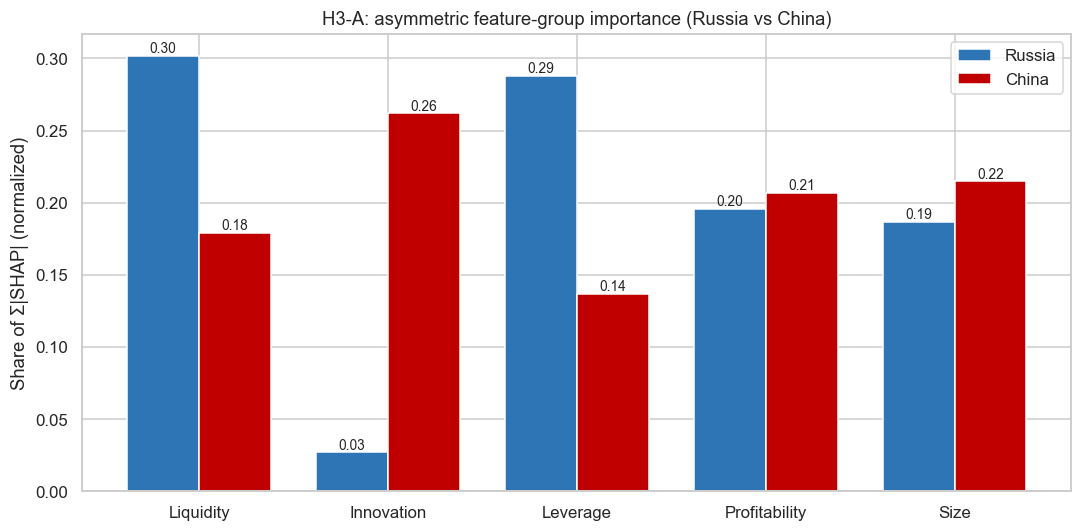

saved -> reports/cross_country/h3a_group_shares.png


In [11]:
# Визуализация: bar chart долей групп side-by-side
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Liquidity', 'Innovation', 'Leverage', 'Profitability', 'Size']
x = np.arange(len(order))
width = 0.38
ax.bar(x - width/2, [groups_df.loc[g, 'Russia share'] for g in order],
       width, label='Russia', color='#2E75B6')
ax.bar(x + width/2, [groups_df.loc[g, 'China share']  for g in order],
       width, label='China',  color='#C00000')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('Share of Σ|SHAP| (normalized)')
ax.set_title('H3-A: asymmetric feature-group importance (Russia vs China)')
ax.legend()
for i, g in enumerate(order):
    ax.text(i - width/2, groups_df.loc[g, 'Russia share'],
            f'{groups_df.loc[g, "Russia share"]:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, groups_df.loc[g, 'China share'],
            f'{groups_df.loc[g, "China share"]:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig.savefig(REPORTS / 'h3a_group_shares.png', dpi=160, bbox_inches='tight')
plt.show()
print('saved -> reports/cross_country/h3a_group_shares.png')

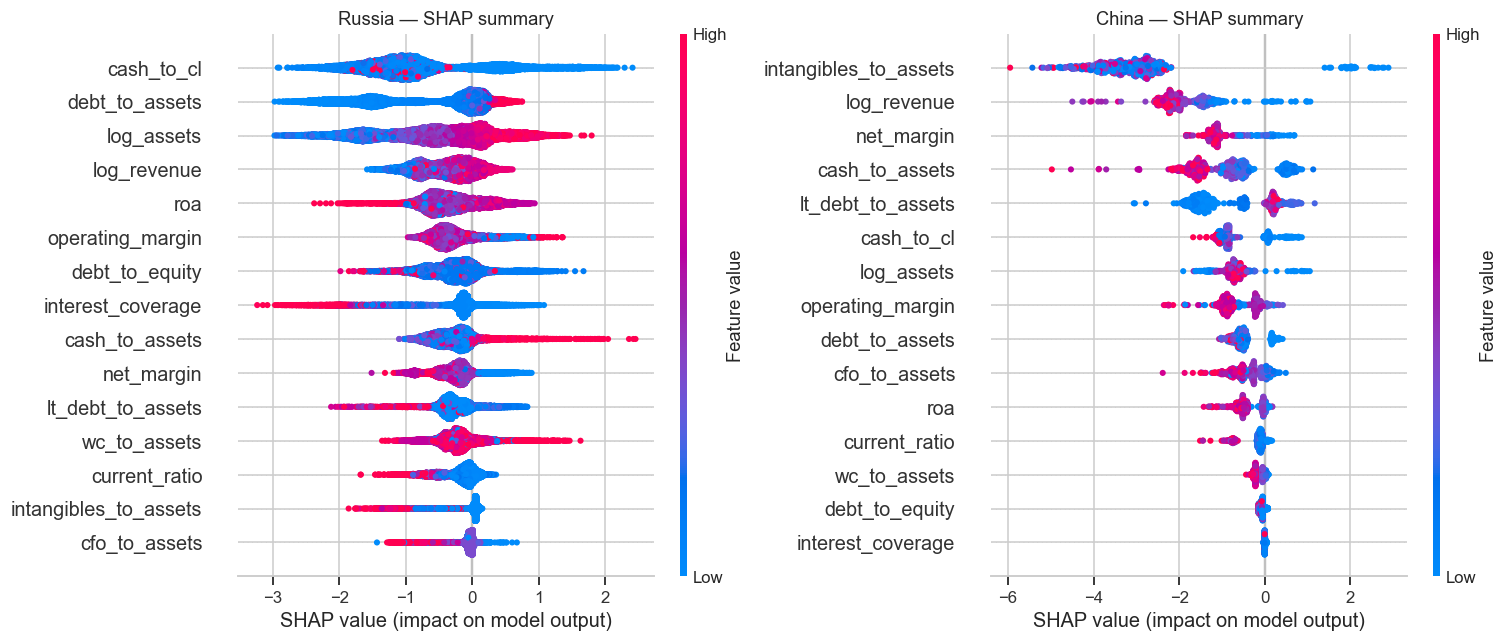

saved -> reports/cross_country/h3a_shap_side_by_side.png


In [12]:
# SHAP summary side-by-side (для визуальной защиты)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
shap.summary_plot(ru_sv, ru_Xte, feature_names=FEATURES, show=False, plot_size=None)
axes[0].set_title('Russia — SHAP summary')
plt.sca(axes[1])
shap.summary_plot(cn_sv, cn_Xte, feature_names=FEATURES, show=False, plot_size=None)
axes[1].set_title('China — SHAP summary')
plt.tight_layout()
fig.savefig(REPORTS / 'h3a_shap_side_by_side.png', dpi=160, bbox_inches='tight')
plt.show()
print('saved -> reports/cross_country/h3a_shap_side_by_side.png')

## 8. Verdict H3-A

In [13]:
ru_dominant = ru_groups.idxmax()
cn_dominant = cn_groups.idxmax()
ru_top_share = groups_df.loc[ru_dominant, 'Russia share']
cn_top_share = groups_df.loc[cn_dominant, 'China share']

NL = '\n'
lines = ['# H3-A - Cross-Country Asymmetric Feature Importance' + NL]
lines.append('## TTC single-split (group-aware company-level 80/20)')
for c, auc, pr, auc_ci, pr_ci in [
    ('Russia', ru_auc_te, ru_pr_te, ru_roc_ci, ru_pr_ci),
    ('China',  cn_auc_te, cn_pr_te, cn_roc_ci, cn_pr_ci),
]:
    lines.append(f'* **{c}**: ROC-AUC test={auc:.4f} (95%-CI [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]), '
                 f'PR-AUC test={pr:.4f} (95%-CI [{pr_ci[0]:.3f}, {pr_ci[1]:.3f}])')

lines.append(NL + '## PIT macro-lift (placeholder macro - cautious)')
lines.append(f'* Russia dROC median={ru_dmed:+.4f}, 95%-CI=[{ru_dci[0]:+.4f}, {ru_dci[1]:+.4f}]')
lines.append(f'* China  dROC median={cn_dmed:+.4f}, 95%-CI=[{cn_dci[0]:+.4f}, {cn_dci[1]:+.4f}]')
ru_sig = ru_dci[0] > 0
cn_sig = cn_dci[0] > 0
lines.append(f'* Russia significant lift: {ru_sig}')
lines.append(f'* China  significant lift: {cn_sig}')
lines.append('> Placeholder macro - real H3-lift conclusions only after IMF WEO swap.')

lines.append(NL + '## H3-A group-importance structure (main test)')
lines.append(f'* **Russia top group:** {ru_dominant} ({ru_top_share:.1%} of total SHAP mass)')
lines.append(f'* **China  top group:** {cn_dominant} ({cn_top_share:.1%} of total SHAP mass)')
lines.append(f'* Russia top-3 features: {", ".join(ru_top.index)}')
lines.append(f'* China  top-3 features: {", ".join(cn_top.index)}')

if ru_dominant != cn_dominant:
    verdict = (f'[OK] H3-A CONFIRMED: dominant risk-factor groups differ - '
               f'{ru_dominant} in Russia vs {cn_dominant} in China. '
               f'Structural asymmetry matches the capital-regime hypothesis.')
elif ru_dominant == cn_dominant == 'Liquidity':
    verdict = ('[WARN] H3-A partial: both countries show Liquidity dominance; '
               'interpret as "liquidity is universal for IT" - not matching asymmetry expectation.')
else:
    verdict = (f'[WARN] H3-A partial: top group matches ({ru_dominant}); '
               f'asymmetry weaker than expected - discuss economically.')
lines.append(NL + verdict)
print(verdict)

[OK] H3-A CONFIRMED: dominant risk-factor groups differ - Liquidity in Russia vs Innovation in China. Structural asymmetry matches the capital-regime hypothesis.


In [14]:
summary_path = REPORTS / 'h3a_summary.md'
summary_path.write_text('\n'.join(lines), encoding='utf-8')
print(f'Summary written: {summary_path}')
print()
print('Artifacts in reports/cross_country/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size/1024:.1f} KB)')

Summary written: ..\reports\cross_country\h3a_summary.md

Artifacts in reports/cross_country/:
  h3_group_importance.csv  (0.2 KB)
  h3_pit_vs_ttc.csv  (0.2 KB)
  h3_shap_side_by_side.png  (344.9 KB)
  h3_summary.md  (0.8 KB)
  h3_top3_features.csv  (0.3 KB)
  h3a_group_importance.csv  (0.2 KB)
  h3a_group_shares.png  (58.0 KB)
  h3a_pit_vs_ttc.csv  (0.2 KB)
  h3a_shap_side_by_side.png  (358.4 KB)
  h3a_summary.md  (1.1 KB)
  h3a_top3_features.csv  (0.3 KB)
  h3a_ttc_bootstrap_ci.csv  (0.2 KB)
  h3a_ttc_table.csv  (0.2 KB)


## 9. Инструкция: как подключить реальную IMF WEO

1. Скачать CSV с https://www.imf.org/en/Publications/WEO/weo-database (variable selection: `NGDP_RPCH` и `PCPIPCH`; countries: Russian Federation, China).
2. Открыть ячейку с `_MACRO_PLACEHOLDER` и заменить числа.
3. Re-run notebook полностью. Остальной код (split, bootstrap, SHAP) заработает без правок.

Для **robustness check**: в `load_macro` можно добавить третью переменную (например, key rate / CNY interbank rate); `compare_ttc_vs_pit` берёт любой список макро-колонок, если добавить их в `X_pit`.